In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from fractions import Fraction

In [32]:
def time_axis(fs, duration):
    return np.arange(0, duration, 1/fs)
def gen_signal(f, t, a, p):
    return a*np.sin(2*np.pi*f*t + p)
def spectrum(x, fs, NFFT = -1):
    N = len(x)
    if NFFT == -1:
        NFFT = N
    X = np.fft.fft(x, NFFT)
    X = X[:N//2+1]
    mag = np.abs(X)
    freq= np.arange(len(mag)) * fs/N
    return freq, mag
def normalize(x):
    return (x - np.mean(x))/np.std(x)

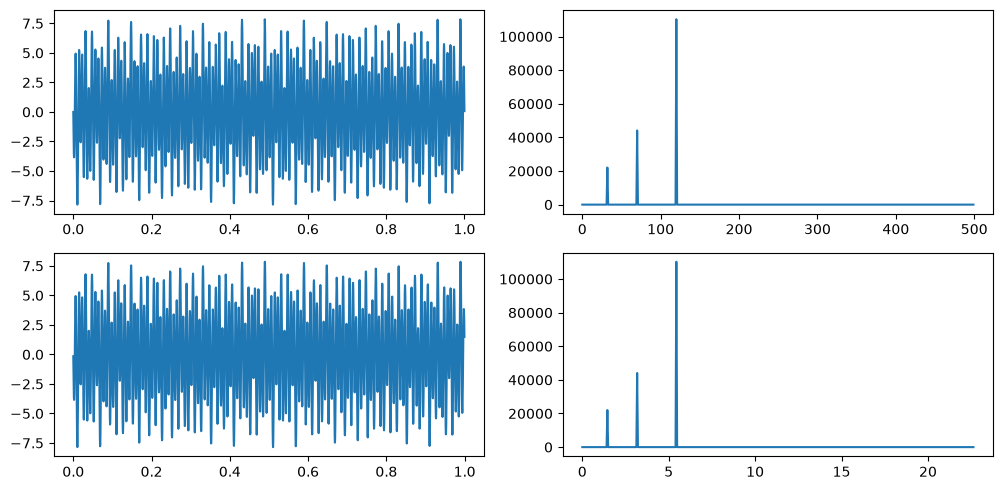

In [24]:
fs_old = 44100 # fs_down
duration = 1
t = time_axis(fs_old, duration)
x = gen_signal(32, t, 1, np.pi) + gen_signal(70, t, 2, 0) + gen_signal(120, t, 5, -np.pi)
freq, mag = spectrum(x, fs_old)
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1); plt.plot(t, x)
plt.subplot(2, 2, 2); plt.plot(freq[:500], mag[:500])

fs_new = 2000 # fs_up
ratio = Fraction(fs_new, fs_old)#;  print(ratio)
L_lm, M_lm = ratio.numerator, ratio.denominator#; print(L_lm, M_lm)
x_resample = signal.resample_poly(x, L_lm, M_lm)
t_resample = np.arange(len(x_resample)) / fs_new
freq, mag  = spectrum(x, fs_new)

plt.subplot(2, 2, 3); plt.plot(t_resample, x_resample)
plt.subplot(2, 2, 4); plt.plot(freq[:500], mag[:500])

plt.tight_layout()

>we have the original signal with 44100 hz of frequency, then we downsampling it to only 2000 hz.
>
>we do it by resample_poly up by 20 then down by 441.

# Alignment

1000


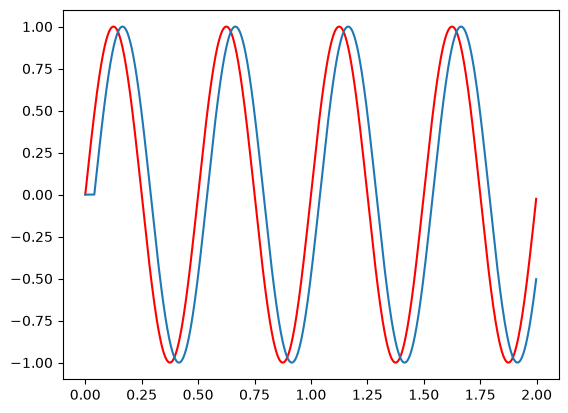

In [31]:
fs = 500
duration = 2
t = time_axis(fs, duration)
x1 = gen_signal(2, t, 1, 0)
delay = 20
x2 = np.zeros(len(x1))
x2[delay:] = x1[:-delay]
plt.plot(t, x1, color = "red")
plt.plot(t, x2)
print(len(x1))

In [39]:
x1 = normalize(x1)
x2 = normalize(x2)

# plt.plot(t, x1, color = "red")
# plt.plot(t, x2)

corr = signal.correlate(x1, x2, mode = "full") #;print(corr)
lags = signal.correlation_lags(len(x1), len(x2), mode = "full") #;print(lags)
d = lags[np.argmax(corr)] ;print(d)


-20


check if exact number of sample delay between two signals : x1, x2

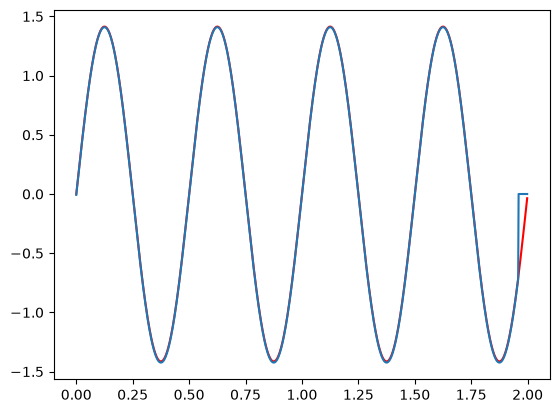

In [40]:
# how to fix it
y = np.zeros(len(x2))
if d > 0:
    y[d:] = x2[:-d]
elif d < 0:
    y[:d] = x2[-d:]
plt.plot(t, x1, color = 'red')
plt.plot(t, y)